# Physics-Informed Neural Networks: решение уравнения Гельмгольца и классификация звука

Physics-Informed Neural Network учится не на размеченных данных, а на самом дифференциальном уравнении: в функцию потерь идут невязка уравнения и ошибка на граничных условиях. У классических PINN есть неприятное свойство — число коллокационных точек растёт как $O(N^d)$ по размерности задачи, и уже на трёхмерной постановке это становится дорого.

Separable PINN решает проблему архитектурно. Вместо одной сети с многомерным входом $(x,y,z) \to u$ обучаются отдельные body-сети по каждой координате, а решение собирается CP-декомпозицией тензора:

$$u(x,y,z) = \sum_{j=1}^r f_j^{(1)}(x) \cdot f_j^{(2)}(y) \cdot f_j^{(3)}(z)$$

Это меняет асимптотику на $O(Nd)$. В первой части я реализую такую архитектуру ([статья](https://arxiv.org/pdf/2306.15969)) и обучаю её решать трёхмерное уравнение Гельмгольца $\nabla^2 u + k^2 u = q$ на кубе $[-1,1]^3$ с нулевыми граничными условиями Дирихле, проверяя результат по известному аналитическому решению.

Вторая часть — про сигналы другой природы. Классификация городских звуков UrbanSound8K (10 классов, 8732 фрагмента): извлечение мел-спектрограмм и своя свёрточная архитектура поверх них. Мел-шкала здесь не косметика, а способ сжать тысячи частотных бинов до сотни перцептивно осмысленных и превратить одномерный сигнал в картинку, с которой CNN умеет работать.

Стек: PyTorch (forward-mode autodiff для SPINN), torchaudio/librosa.

---


## Нейронные сети ##

В этой работе две независимые части:

- Separable Physics-Informed Neural Network (SPINN) для решения 3D-уравнения Гельмгольца на кубе `[-1, 1]^3` с нулевыми граничными условиями Дирихле. Реализуем дочернюю модель от `BaseModel`, используя архитектуру SPINN и обучим её, минимизируя невязку PDE и ошибку на границе.

- Классификация звуков UrbanSound8K на CNN. Будем извлекать мел-спектрограммы и строить собственную сверточную архитектуру. Оцениваем по accuracy на тесте.

In [1]:
#!pip install pytorch==2.1.1 torchvision==0.16.1 torchaudio==2.1.1 scikit-learn==1.3.2 tqdm==4.67.0 matplotlib==3.7.2 soundata

In [11]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, utils as vutils

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


from typing import Tuple, List, Optional
from tqdm.auto import tqdm, trange
from IPython import display

import soundata
import librosa
import librosa.display
from IPython.display import Audio

In [12]:
torch.manual_seed(1337)

In [13]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

## 1. Separable Physics Informed Neural Network для решения уравнения Гельмгольца.

Physics-Informed Neural Networks (PINNs) - это класс нейросетевых моделей, которые используют не только данные, но и уравнения физики для обучения.

В отличие от обычных нейросетей, PINN оптимизирует функцию потерь, включающую как ошибку на данных (например, граничные и начальные условия), так и невязку дифференциального уравнения (например, уравнения Пуассона).

Таким образом, модель учится решать задачу так, чтобы удовлетворять законам физики.

Это позволяет PINN эффективно работать даже при ограниченном количестве наблюдений, обеспечивая физически осмысленные решения и связывая машинное обучение с методами численного анализа.

### Separable PINN

**Separable PINN (SPINN)** - это архитектурная модификация обычных PINN, которая решает фундаментальную проблему: **вычислительную сложность при работе с многомерными PDE**.

Так как PINNs используют не только данные, но и уравнения физики для обучения, то для многомерных задач количество коллокационных точек растет экспоненциально ($N^d$), что приводит к огромным вычислительным затратам.

В отличие от классических PINN, где одна нейросеть принимает многомерный вход $(x, y, z, t) \to u$, SPINN использует:

- Несколько отдельных маленьких сетей - по одной для каждой координаты.
- Forward-mode automatic differentiation вместо обратной моды (reverse-mode).
- Факторизуемые координаты - точки коллокации формируют решетку (lattice structure).

Это позволяет экспоненциально сократить количество сетевых операций:

$$
O(N^d) \to O(Nd)
$$

где $N$ - разрешение по каждой оси, $d$ - размерность задачи.


### Архитектура SPINN

Для $d$-мерной задачи SPINN состоит из двух ключевых компонентов:

#### 1. Body Networks (независимые сети для каждой координаты)

$$
f^{(\theta_i)}: \mathbb{R} \to \mathbb{R}^r, \quad i = 1, 2, \ldots, d
$$

где:
- $f^{(\theta_i)}$ - $i$-я body-сеть (MLP с параметрами $\theta_i$)
- Каждая сеть обрабатывает только одну координату ($x_1$, $x_2$, ..., или $x_d$)
- $r$ - ранг декомпозиции (размер выходного вектора признаков)

#### 2. Feature Merging (CP-декомпозиция тензора)

Финальное решение получается через простую операцию произведения и суммирования:

$$
\hat{u}(x_1, x_2, \ldots, x_d) = \sum_{j=1}^{r} \prod_{i=1}^{d} f_j^{(\theta_i)}(x_i)
$$

где:
- $f_j^{(\theta_i)}(x_i)$ - $j$-я компонента выхода $i$-й body-сети
- $r$ - ранг декомпозиции (количество суммируемых членов)

**Интерпретация.** Это аналог CP-декомпозиции (Canonical Polyadic decomposition) тензора - решение представляется как сумма $r$ тензоров ранга 1:

$$
\hat{u} = \sum_{j=1}^{r} \mathbf{f}_j^{(1)} \otimes \mathbf{f}_j^{(2)} \otimes \cdots \otimes \mathbf{f}_j^{(d)}
$$

Уравнение Гельмгольца в трехмерном случае имеет вид:

$$
\nabla^2 u(x, y, z) + k^2 u(x, y, z) = q(x, y, z), \quad (x,y,z) \in \Omega
$$

где:
- $u(x,y,z)$ - неизвестная функция (амплитуда волны)
- $k$ - волновое число
- $q(x,y,z)$ - правая часть (источник)
- на границе области $\partial \Omega$ задаются граничные условия: $u = 0$

### Аналитическое решение:

Для тестирования модели используется:

$$
u(x,y,z) = \sin(a_1\pi x) \cdot \sin(a_2\pi y) \cdot \sin(a_3\pi z)
$$

где в коде: $a_1 = 1$, $a_2 = 1$, $a_3 = 1$.

Метод `reference_solution(x, y, z)`:

```python
def reference_solution(self, x, y, z):
    return (torch.sin(self.a1 * np.pi * x) *
            torch.sin(self.a2 * np.pi * y) *
            torch.sin(self.a3 * np.pi * z))
```


### Источник (правая часть):

Источник $q(x,y,z)$ получается подстановкой аналитического решения в уравнение Гельмгольца:

$$
q(x,y,z) = \nabla^2 u + k^2 u = \left[-(a_1\pi)^2 - (a_2\pi)^2 - (a_3\pi)^2 + k^2\right] u(x,y,z)
$$

Метод `function_of_source(x, y, z)`:

```python
def function_of_source(self, x, y, z):
    u = self.reference_solution(x, y, z)
    laplacian_coef = -(self.a1 * np.pi)**2 - (self.a2 * np.pi)**2 - (self.a3 * np.pi)**2
    return (laplacian_coef + self.k**2) * u
```


### Граничные условия:

На всех 6 гранях куба $\Omega = [-1, 1]^3$ задаются нулевые граничные условия Дирихле:

$$
u(x,y,z) = 0, \quad (x,y,z) \in \partial \Omega
$$

Это соответствует физическому условию отсутствия волны на границе (например, жесткое закрепление мембраны).


In [14]:
def helmholtz3d_exact_u(a1, a2, a3, x, y, z):
    return torch.sin(a1*torch.pi*x) * torch.sin(a2*torch.pi*y) * torch.sin(a3*torch.pi*z)

In [15]:
def relative_l2(u_pred, u_true):
    """Относительная L2 ошибка: ||u_pred - u_true|| / ||u_true||"""
    return torch.linalg.norm(u_pred - u_true) / torch.linalg.norm(u_true)


def plot_helmholtz3d(x, y, z, u):
    x = x.detach().cpu().numpy().flatten()
    y = y.detach().cpu().numpy().flatten()
    z = z.detach().cpu().numpy().flatten()
    u = u.detach().cpu().numpy().flatten()

    u_norm = (u - u.min()) / (u.max() - u.min())

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        x, y, z,
        c=u_norm,
        s=1,
        cmap='seismic',
        vmin=0, vmax=1,
        alpha=0.75,
        edgecolors='none'
    )

    ax.set_title('U(x, y, z)', fontsize=20)
    ax.set_xlabel('x', fontsize=18)
    ax.set_ylabel('y', fontsize=18)
    ax.set_zlabel('z', fontsize=18)

    cbar = plt.colorbar(scatter, shrink=0.8)
    cbar.set_label('u(x,y,z)', fontsize=16)

    plt.tight_layout()
    plt.show()



def plot_losses(loss_history, residual_history, boundary_history,
                error_history, log_iter, title_prefix=""):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.semilogy(loss_history, label='Total Loss')
    ax1.semilogy(residual_history, label='Residual Loss')
    ax1.semilogy(boundary_history, label='Boundary Loss')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_title(f'{title_prefix}Training Losses')

    iters = np.arange(0, len(error_history) * log_iter, log_iter)
    ax2.semilogy(iters, error_history, 'r-', label='Relative L2')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_title(f'{title_prefix}Relative L2 Error')

    plt.tight_layout()
    plt.show()



def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true, batch_size=20000):
    """
    Вычисление относительной L2 ошибки на тестовой сетке.
    Возвращает u_pred той же формы, что и u_true.
    """
    device = next(model.parameters()).device

    x = x_grid.to(device)
    y = y_grid.to(device)
    z = z_grid.to(device)
    u_true = u_true.to(device)

    coords = torch.stack([x.flatten(), y.flatten(), z.flatten()], dim=1)

    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, coords.shape[0], batch_size):
            batch_coords = coords[i:i+batch_size]
            preds.append(model(batch_coords))

    u_pred = torch.cat(preds, dim=0).reshape(u_true.shape)
    u_true_flat = u_true.flatten()
    u_pred_flat = u_pred.flatten()

    error = relative_l2(u_pred_flat, u_true_flat)

    model.train()
    return error, u_pred




def resample_collocation_points(model, NC, domain_size=1.0):
    """
    Ресэмплирование коллокационных точек, чтобы сетка менялась, а
    факторизованная структура сохранялась.
    """
    N = int(round(NC ** (1/3)))  # корректный кубический корень

    base = torch.linspace(-domain_size, domain_size, N, device=model.device)

    xx, yy, zz = torch.meshgrid(base, base, base, indexing='ij')

    # Случайный джиттер
    jitter = (2 * torch.rand_like(xx) - 1) * (2 * domain_size / N)

    xc = (xx + jitter).flatten().requires_grad_(True)
    yc = (yy + jitter).flatten().requires_grad_(True)
    zc = (zz + jitter).flatten().requires_grad_(True)

    return xc, yc, zc

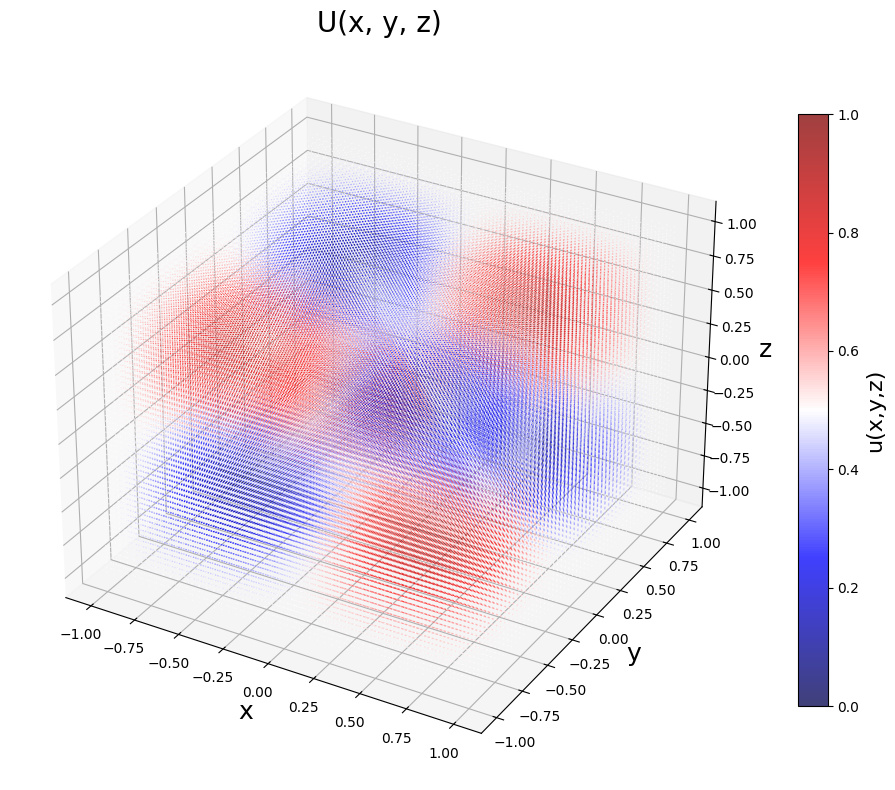

In [16]:
N_test = 50
x_test = torch.linspace(-1, 1, N_test, device=device)
y_test = torch.linspace(-1, 1, N_test, device=device)
z_test = torch.linspace(-1, 1, N_test, device=device)

xx_test, yy_test, zz_test = torch.meshgrid(x_test, y_test, z_test, indexing='ij')

u_test = helmholtz3d_exact_u(1, 1, 1, xx_test, yy_test, zz_test)

plot_helmholtz3d(xx_test, yy_test, zz_test, u_test)

Напишем дочерний класс от BaseModel, который сможет решить трёхмерное уравнение Гельмгольца.

Для этого необходимо реализовать три независимые body-сети и соответствующую формулу (уравнение 5) из статьи https://arxiv.org/pdf/2306.15969:

$$u(x,y,z) = \sum_{j=1}^r \left[ f_j^{(1)}(x) \cdot f_j^{(2)}(y) \cdot f_j^{(3)}(z) \right]$$
        
где $f^{(i)}$ - это i-я body-сеть, $f_j^{(i)}$ - j-я компонента её выхода.

In [17]:
class BaseModel(nn.Module):
    """
    Базовая модель для 3D уравнения Гельмгольца на кубе [-1,1]³.

    PDE:  ∇²u(x,y,z) + k²u(x,y,z) = q(x,y,z)
    BC:   u(x,y,z) = 0 на каждой из 6 граней куба.

    Manufactured solution: u = sin(a₁πx)sin(a₂πy)sin(a₃πz)
    """

    def __init__(self,
                 x_min: float = -1., x_max: float = 1.,
                 y_min: float = -1., y_max: float = 1.,
                 z_min: float = -1., z_max: float = 1.,
                 k: float = 1.0,
                 a1: int = 1, a2: int = 1, a3: int = 1,
                 N: int = 32,
                 device: torch.device = None):
        super().__init__()
        self.x_min, self.x_max = x_min, x_max
        self.y_min, self.y_max = y_min, y_max
        self.z_min, self.z_max = z_min, z_max
        self.N = N
        self.k = k  # волновое число
        self.a1, self.a2, self.a3 = a1, a2, a3
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.mse = nn.MSELoss(reduction="mean")

        # Граничные точки (6 граней куба)
        self._init_boundary_points()

    def _init_boundary_points(self):
        """Инициализация точек на 6 гранях куба."""
        N = self.N

        # Создаем линейные сетки для каждой оси
        lin_x = torch.linspace(self.x_min, self.x_max, N)
        lin_y = torch.linspace(self.y_min, self.y_max, N)
        lin_z = torch.linspace(self.z_min, self.z_max, N)

        # Грань 1: x = x_min (левая грань)
        yy, zz = torch.meshgrid(lin_y, lin_z, indexing='ij')
        x_bc1 = torch.full_like(yy, self.x_min).reshape(-1, 1)
        y_bc1 = yy.reshape(-1, 1)
        z_bc1 = zz.reshape(-1, 1)

        # Грань 2: x = x_max (правая грань)
        yy, zz = torch.meshgrid(lin_y, lin_z, indexing='ij')
        x_bc2 = torch.full_like(yy, self.x_max).reshape(-1, 1)
        y_bc2 = yy.reshape(-1, 1)
        z_bc2 = zz.reshape(-1, 1)

        # Грань 3: y = y_min (нижняя грань)
        xx, zz = torch.meshgrid(lin_x, lin_z, indexing='ij')
        x_bc3 = xx.reshape(-1, 1)
        y_bc3 = torch.full_like(xx, self.y_min).reshape(-1, 1)
        z_bc3 = zz.reshape(-1, 1)

        # Грань 4: y = y_max (верхняя грань)
        xx, zz = torch.meshgrid(lin_x, lin_z, indexing='ij')
        x_bc4 = xx.reshape(-1, 1)
        y_bc4 = torch.full_like(xx, self.y_max).reshape(-1, 1)
        z_bc4 = zz.reshape(-1, 1)

        # Грань 5: z = z_min (передняя грань)
        xx, yy = torch.meshgrid(lin_x, lin_y, indexing='ij')
        x_bc5 = xx.reshape(-1, 1)
        y_bc5 = yy.reshape(-1, 1)
        z_bc5 = torch.full_like(xx, self.z_min).reshape(-1, 1)

        # Грань 6: z = z_max (задняя грань)
        xx, yy = torch.meshgrid(lin_x, lin_y, indexing='ij')
        x_bc6 = xx.reshape(-1, 1)
        y_bc6 = yy.reshape(-1, 1)
        z_bc6 = torch.full_like(xx, self.z_max).reshape(-1, 1)

        # Регистрируем как buffers
        for i, (x_bc, y_bc, z_bc) in enumerate([
            (x_bc1, y_bc1, z_bc1), (x_bc2, y_bc2, z_bc2),
            (x_bc3, y_bc3, z_bc3), (x_bc4, y_bc4, z_bc4),
            (x_bc5, y_bc5, z_bc5), (x_bc6, y_bc6, z_bc6)
        ], 1):
            coords = torch.cat([x_bc, y_bc, z_bc], dim=-1).to(self.device)
            self.register_buffer(f"coords_bc{i}", coords)
            self.register_buffer(f"zeros_bc{i}", torch.zeros(coords.shape[0], 1).to(self.device))

    # Физика задачи
    def reference_solution(self, x, y, z):
        """
        Аналитическое решение (manufactured solution):
        u(x,y,z) = sin(a₁πx) * sin(a₂πy) * sin(a₃πz)
        """
        return (torch.sin(self.a1 * np.pi * x) *
                torch.sin(self.a2 * np.pi * y) *
                torch.sin(self.a3 * np.pi * z))

    def function_of_source(self, x, y, z):
        """
        Правая часть q(x,y,z), полученная из точного решения:
        Из уравнения Гельмгольца: ∇²u + k²u = q
        Подставляя manufactured solution:
        q = -(a₁π)²u - (a₂π)²u - (a₃π)²u + k²u
        """
        u = self.reference_solution(x, y, z)
        laplacian_term = (-(self.a1 * np.pi)**2 -
                         (self.a2 * np.pi)**2 -
                         (self.a3 * np.pi)**2) * u
        return laplacian_term + self.k**2 * u

    def calculate_loss(self, states: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        states: (B, 3) с колонками [x, y, z]
        Возвращает (loss_PDE, loss_BC)
        """
        x, y, z = states[:, 0], states[:, 1], states[:, 2]
        loss_pde = self.calculate_pde_loss(x, y, z)
        loss_bc = self.calculate_bc_loss()
        return loss_pde, loss_bc

    def calculate_pde_loss(self, x: torch.Tensor, y: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        """
        MSE по PDE-резидуалу: r = ∇²u + k²u - q(x,y,z)

        Использует forward-mode AD для эффективного вычисления производных.
        В статье показано, что для SPINN forward-mode быстрее reverse-mode!

        Уравнение Гельмгольца:
        ∂²u/∂x² + ∂²u/∂y² + ∂²u/∂z² + k²u = q
        """
        # Клонируем и требуем градиенты для forward-mode AD
        x = x.clone().detach().requires_grad_(True)
        y = y.clone().detach().requires_grad_(True)
        z = z.clone().detach().requires_grad_(True)

        # Формируем координаты и вычисляем u
        coords = torch.stack([x, y, z], dim=1)  # (B, 3)
        u = self.forward(coords)  # (B,)

        # Первые производные (используем forward-mode AD)
        u_x = self._compute_gradient(u, x)  # ∂u/∂x
        u_y = self._compute_gradient(u, y)  # ∂u/∂y
        u_z = self._compute_gradient(u, z)  # ∂u/∂z

        # Вторые производные
        u_xx = self._compute_gradient(u_x, x)  # ∂²u/∂x²
        u_yy = self._compute_gradient(u_y, y)  # ∂²u/∂y²
        u_zz = self._compute_gradient(u_z, z)  # ∂²u/∂z²

        # Лапласиан: ∇²u = ∂²u/∂x² + ∂²u/∂y² + ∂²u/∂z²
        laplace_u = u_xx + u_yy + u_zz

        # Источник q(x,y,z)
        q = self.function_of_source(x, y, z)

        # Резидуал уравнения Гельмгольца: ∇²u + k²u - q = 0
        residual = laplace_u + self.k**2 * u - q

        return self.mse(residual, torch.zeros_like(residual))

    @staticmethod
    def _compute_gradient(output: torch.Tensor, input_var: torch.Tensor) -> torch.Tensor:
        """
        Вычисляет градиент output по input_var используя forward-mode AD.

        Forward-mode AD эффективен когда выход - вектор большой размерности,
        а вход - скаляр, что как раз наш случай в SPINN!
        """
        grad = torch.autograd.grad(
            outputs=output,
            inputs=input_var,
            grad_outputs=torch.ones_like(output),
            create_graph=True,
            retain_graph=True
        )[0]
        return grad


    def calculate_bc_loss(self) -> torch.Tensor:
        """
        MSE по Дирихле на 6 гранях: u=0.
        """
        preds = []
        targets = []

        for i in range(1, 7):
            coords_bc = getattr(self, f"coords_bc{i}")
            zeros = getattr(self, f"zeros_bc{i}")

            u_bc = self.forward(coords_bc)
            if u_bc.dim() == 1:
                u_bc = u_bc.unsqueeze(-1)
            preds.append(u_bc)
            targets.append(zeros)

        return sum(self.mse(p, t) for p, t in zip(preds, targets))

    def forward(self, coords: torch.Tensor) -> torch.Tensor:
        """
        Реализована в наследнике.
        Ожидает coords.shape == (B, 3) с [x, y, z]; возвращает (B, 1) или (B,).
        """
        raise NotImplementedError("Реализуйте forward в наследнике.")

In [35]:
class BaseSPINN(BaseModel):
    def __init__(self,
                 rank: int = 8,
                 hidden_dim: int = 64,
                 n_hidden_layers: int = 3,
                 **kwargs):
        super().__init__(**kwargs)

        self.rank = int(rank)
        self.hidden_dim = int(hidden_dim)
        self.n_hidden_layers = int(n_hidden_layers)

        self.body_x = self._make_body_network()
        self.body_y = self._make_body_network()
        self.body_z = self._make_body_network()

        self.apply(init_tanh_)

    def _make_body_network(self) -> nn.Sequential:
        layers = []
        layers.append(nn.Linear(1, self.hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(self.n_hidden_layers - 1):
            layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(self.hidden_dim, self.rank))
        return nn.Sequential(*layers)

    def forward(self, coords: torch.Tensor) -> torch.Tensor:
        if coords.dim() == 1:
            coords = coords.unsqueeze(0)

        x = coords[:, 0:1]
        y = coords[:, 1:2]
        z = coords[:, 2:3]

        fx = self.body_x(x)   
        fy = self.body_y(y)   
        fz = self.body_z(z)   

        prod = fx * fy * fz   
        u = prod.sum(dim=1, keepdim=True)  

        return u
        

def init_tanh_(m: nn.Module):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain("tanh"))
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [42]:
def train_spinn(model,
                optimizer,
                x_test, y_test, z_test, u_test,
                epochs=10000,
                log_iter=100,
                resample_iter=100,
                NC=64**3,
                domain_size=1.0,
                device='cuda'):
    

    history = {'loss': [], 'residual': [], 'boundary': [], 'error': []}
    best_error = float('inf')
    best_u = None
    pbar = trange(1, epochs + 1)

    for epoch in pbar:

        # Ресэмплирование
        if epoch == 1 or epoch % resample_iter == 0:
            xc, yc, zc = resample_collocation_points(model, NC, domain_size)
            xc, yc, zc = xc.to(device), yc.to(device), zc.to(device)

        optimizer.zero_grad()
        coords = torch.stack([xc, yc, zc], dim=1)

        
        loss_pde, loss_bc = model.calculate_loss(coords)
        loss = loss_pde + loss_bc  # простое суммирование

        loss.backward()
        optimizer.step()

        history['loss'].append(loss.item())
        history['residual'].append(loss_pde.item())
        history['boundary'].append(loss_bc.item())

        if epoch % log_iter == 0:
            error, u_pred = compute_error_on_grid(model, x_test, y_test, z_test, u_test)
            history['error'].append(error.item())

            if error < best_error:
                best_error = error
                best_u = u_pred.clone()
                torch.save(model.state_dict(), "model_spinn.pth")

            display.clear_output(wait=True)
            plot_losses(history['loss'], history['residual'],
                        history['boundary'], history['error'], log_iter)

            if error == best_error:
                print(f"New best error: {best_error:.2e}")
                plot_helmholtz3d(x_test, y_test, z_test, u_pred)

            pbar.set_description(
                f'Loss: {loss.item():.2e} '
                f'(PDE: {loss_pde.item():.2e}, BC: {loss_bc.item():.2e}) | '
                f'Error: {error.item():.2e} | Best: {best_error:.2e}'
            )

    print(f'\nBest error: {best_error:.2e}')
    display.clear_output(wait=True)
    plot_losses(history['loss'], history['residual'],
                history['boundary'], history['error'], log_iter,
                title_prefix="Final ")

    if best_u is not None:
        print("\nBest solution:")
        plot_helmholtz3d(x_test, y_test, z_test, best_u)

    return history, best_error, best_u

In [43]:
EPOCHS = 1000
LOG_ITER = 100
RESAMPLE_ITER = 100  # как в статье
NC = 64*3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [44]:
model = BaseSPINN(
    rank=32,
    hidden_dim=256,
    n_hidden_layers=4,
    N=32,
    k=1.0,
    a1=1, a2=1, a3=1
).to(device)

model.load_state_dict(torch.load("model_spinn.pth"))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [45]:
torch.cuda.is_available()

True

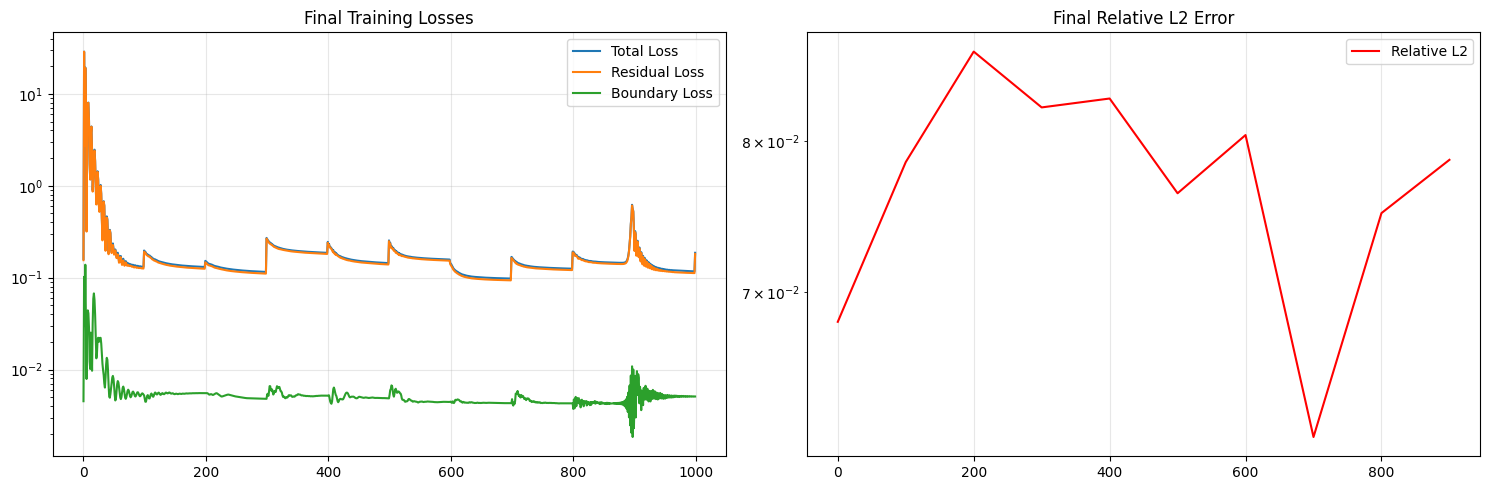


Best solution:


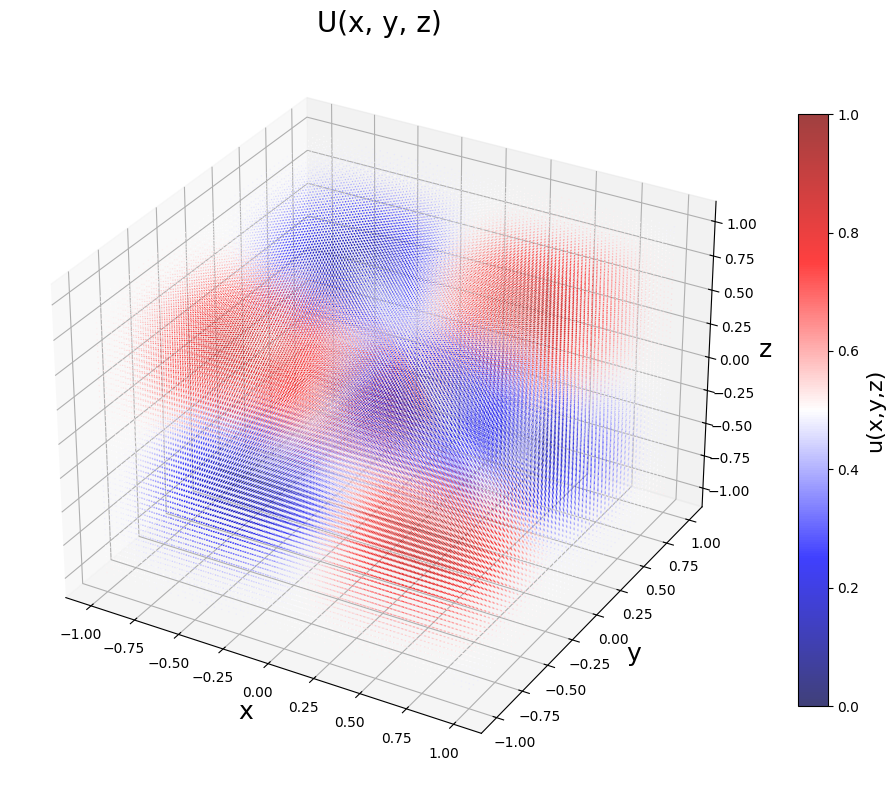

In [46]:
history, best_error, best_u = train_spinn(
    model=model,
    optimizer=optimizer,
    x_test=xx_test,
    y_test=yy_test,
    z_test=zz_test,
    u_test=u_test,
    epochs=1000,
    log_iter=LOG_ITER,
    resample_iter=RESAMPLE_ITER,
    NC=NC,
    domain_size=1.0,
    device=device
)

In [ ]:
mse = ((u_test.cpu().numpy() - best_u.cpu().numpy()) ** 2).mean()

## 2. Классификация звуков

Источники: [markovka17/dla](https://github.com/markovka17/dla), [audacity](https://manual.audacityteam.org/man/spectrogram_view.html)

## UrbanSound8K



Мы будем работать с датасетом UrbanSound8K (US8K).

8732 размеченных фрагмента урбан-звуков (≤ 4 с), 10 классов: `air_conditioner`, `car_horn`, `children_playing`, `dog_bark`, `drilling`, `engine_idling`, `gun_shot`, `jackhammer`, `siren`, `street_music`.

Разбит на 10 фолдов для кросс-валидации; в этом ноутбуке используем "канонично": фолды 1–8 → train, 9 → val, 10 → test.

df = https://urbansounddataset.weebly.com/urbansound8k.html

Структура датасета:
```
UrbanSound8K/
├── audio/
│   ├── fold1/
│   ├── fold2/
│   └── ...
└── metadata/
    └── UrbanSound8K.csv
```

In [48]:
dataset = soundata.initialize('urbansound8k')
dataset.download()
dataset.validate()

example_clip = dataset.choice_clip()
print(example_clip)

INFO: Downloading ['all', 'index']. Index is being stored in /home/user/miniconda3/envs/torch_gpu/lib/python3.10/site-packages/soundata/datasets/indexes, and the rest of files in /home/user/sound_datasets/urbansound8k
INFO: [all] downloading UrbanSound8K.tar.gz
INFO: /home/user/sound_datasets/urbansound8k/UrbanSound8K.tar.gz already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.
INFO: /home/user/sound_datasets/urbansound8k/UrbanSound8K_README.txt already exists. Run with force_overwrite=True to download from scratch
INFO: /home/user/sound_datasets/urbansound8k/metadata already exists. Run with force_overwrite=True to download from scratch
INFO: /home/user/sound_datasets/urbansound8k/FREESOUNDCREDITS.txt already exists. Run with force_overwrite=True to download from scratch
INFO: /home/user/sound_datasets/urbansound8k/audio already exists. Run with force_overwrite=True to download from scratch
INFO: [index] downloading urba

Clip(
  audio_path="/home/user/sound_datasets/urbansound8k/audio/fold3/63095-4-1-4.wav",
  clip_id="63095-4-1-4",
  audio: The clip's audio
            * np.ndarray - audio signal
            * float - sample rate,
  class_id: The clip's class id.
            * int - integer representation of the class label (0-9). See Dataset Info in the documentation for mapping,
  class_label: The clip's class label.
            * str - string class name: air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, siren, street_music,
  fold: The clip's fold.
            * int - fold number (1-10) to which this clip is allocated. Use these folds for cross validation,
  freesound_end_time: The clip's end time in Freesound.
            * float - end time in seconds of the clip in the original freesound recording,
  freesound_id: The clip's Freesound ID.
            * str - ID of the freesound.org recording from which this clip was taken,
  freesound_start_time

In [49]:
DATASET_PATH = '/home/user/sound_datasets/urbansound8k'

metadata = pd.read_csv(os.path.join(DATASET_PATH, 'metadata', 'UrbanSound8K.csv'))

print(f"Всего примеров: {len(metadata)}")
print(f"\nРаспределение по классам:")
print(metadata['class'].value_counts().sort_index())

metadata.head()

Всего примеров: 8732

Распределение по классам:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


#### Провизуализируем аудио

Sample: 21683-9-0-30.wav
Class: street_music
Fold: 7



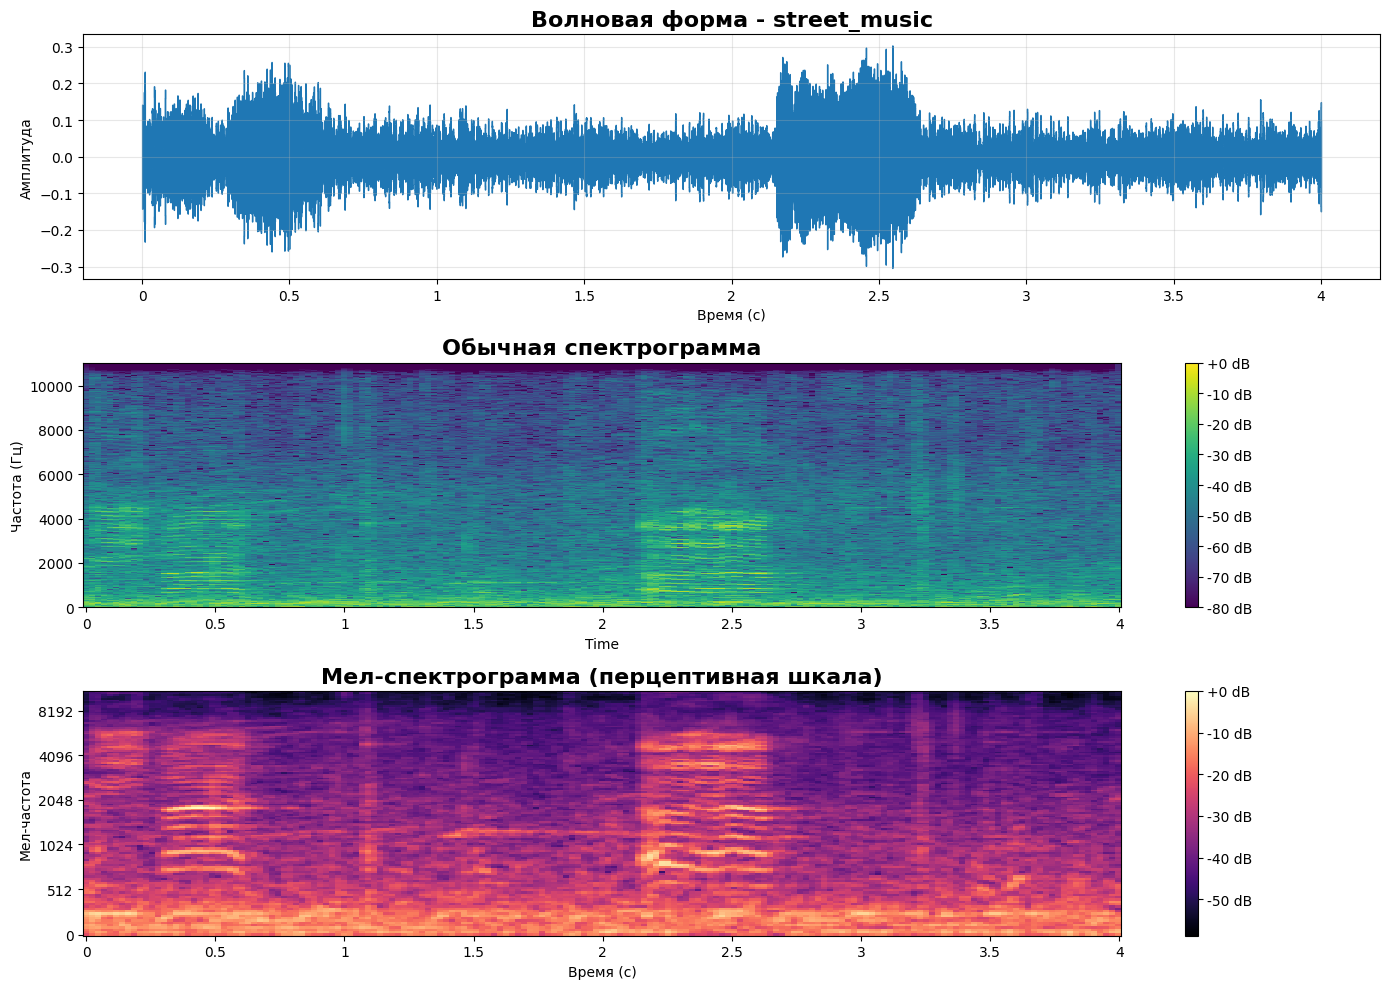


Послушай аудио ниже:


In [50]:
def plot_waveform_and_spectrogram(audio_path, class_name):
    """
    Загрузим аудио и отобразим:
    1. Волну (форма сигнала)
    2. Обычный спектрограмму
    3. Мел-спектрограмму
    """
    # Как работаем с либросой
    y, sr = librosa.load(audio_path, sr=22050)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # 1. Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f'Волновая форма - {class_name}', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Время (с)')
    axes[0].set_ylabel('Амплитуда')
    axes[0].grid(True, alpha=0.3)

    # 2. Обычная спектрограмма
    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=axes[1], cmap='viridis')
    axes[1].set_title('Обычная спектрограмма', fontsize=16, fontweight='bold')
    axes[1].set_ylabel('Частота (Гц)')
    fig.colorbar(img1, ax=axes[1], format='%+2.0f dB')

    # 3. Мел-спектрограмма
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img2 = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[2], cmap='magma')
    axes[2].set_title('Мел-спектрограмма (перцептивная шкала)', fontsize=16, fontweight='bold')
    axes[2].set_ylabel('Мел-частота')
    axes[2].set_xlabel('Время (с)')
    fig.colorbar(img2, ax=axes[2], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

    return y, sr


# Возьмем случайный пример
random_idx = np.random.randint(0, len(metadata))
sample = metadata.iloc[random_idx]

audio_path = os.path.join(DATASET_PATH, 'audio', f'fold{sample.fold}', sample.slice_file_name)
class_name = sample['class']

print(f"Sample: {sample.slice_file_name}")
print(f"Class: {class_name}")
print(f"Fold: {sample.fold}\n")

# Заплотим визуализации
y, sr = plot_waveform_and_spectrogram(audio_path, class_name)

# Проиграем аудио
print("\nПослушай аудио ниже:")
Audio(y, rate=sr)

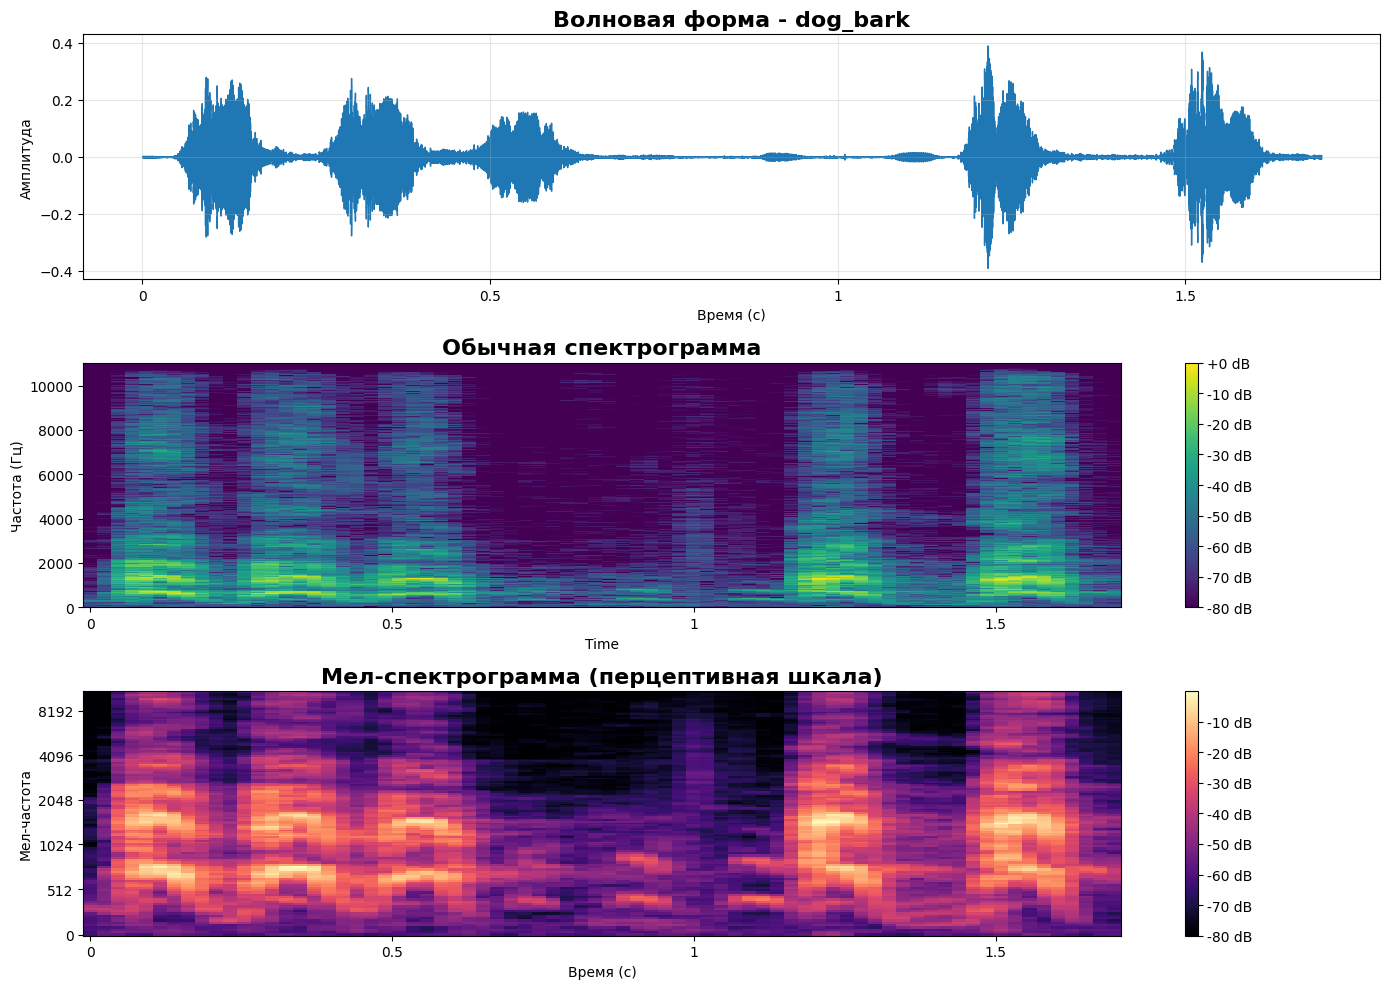

In [51]:
target_class = 'dog_bark'

class_samples = metadata[metadata['class'] == target_class]
sample = class_samples.sample(1).iloc[0]

audio_path = os.path.join(DATASET_PATH, 'audio', f'fold{sample.fold}', sample.slice_file_name)
y, sr = plot_waveform_and_spectrogram(audio_path, target_class)

Audio(y, rate=sr)

### 2.1 Подготовим датасет к обучению модели 

- Прочтем метаданные.
- Заведем несколько констант в `__init__`, чтобы не передавать аргументы по цепочке вручную.
- Будем использовать `os.path.join` (можно и `pathlib`) для сборки путей, чтобы не ошибиться со слэшами.
- Аугментации сделаем детерминированными через фиксированный `seed` при отладке, чтобы воспроизводить ошибки.
- После реализации протестируем `__len__` и `__getitem__` вручную: возьмем 2–3 индекса и сравним метки с исходным metadata.

In [52]:
class UrbanSoundDataset(Dataset):
    def __init__(self, metadata, dataset_path, target_length=4, sr=22050, n_mels=128, augment=False):
        # Сохраняем параметры
        self.metadata = metadata.reset_index(drop=True).copy()
        self.dataset_path = dataset_path
        self.target_length = float(target_length)
        self.sr = int(sr)
        self.n_mels = int(n_mels)
        self.augment = bool(augment)

        # Константы для STFT/мел
        self.n_fft = 2048
        self.hop_length = 512
        self.fmax = 8000
        self.target_samples = int(self.sr * self.target_length)

        # Label encoding
        self.le = LabelEncoder()
        self.metadata['label_idx'] = self.le.fit_transform(self.metadata['class'])
        self.classes = list(self.le.classes_)
        self.num_classes = len(self.classes)

        print(f"сэмплов: {len(self.metadata)}, классы: {self.classes}")

    def __len__(self):
        return len(self.metadata)

    def load_audio(self, file_path):
        y, _ = librosa.load(str(file_path), sr=self.sr, mono=True)
        if len(y) > self.target_samples:
            y = y[:self.target_samples]
        elif len(y) < self.target_samples:
            pad_len = self.target_samples - len(y)
            y = np.pad(y, (0, pad_len), mode='constant', constant_values=0.0)
        return y.astype(np.float32)

    def extract_mel_spectrogram(self, y):
        S = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_fft=self.n_fft, hop_length=self.hop_length,
            n_mels=self.n_mels, fmax=self.fmax, power=2.0
        )
        S_db = librosa.power_to_db(S, ref=np.max)
        mean, std = S_db.mean(), S_db.std()
        if std < 1e-6:  
            std = 1.0
        S_norm = (S_db - mean) / std
        return S_norm.astype(np.float32)

    def augment_audio(self, y):
        if not self.augment:
            return y

        # Случайный циклический сдвиг +/- 1 секунда
        shift = np.random.randint(-self.sr, self.sr + 1)
        if shift != 0:
            y = np.roll(y, shift)
            if shift > 0:
                y[:shift] = 0.0
            else:
                y[shift:] = 0.0

        # Добавление слабого белого шума
        noise_level = 0.002 * np.random.randn()
        y = y + noise_level * np.random.randn(len(y)).astype(np.float32)

        return y

    def __getitem__(self, idx):
        row = self.metadata.iloc[int(idx)]
        file_path = os.path.join(self.dataset_path, 'audio', f'fold{int(row.fold)}', row.slice_file_name)

        y = self.load_audio(file_path)
        y = self.augment_audio(y)
        mel_spec = self.extract_mel_spectrogram(y)

        # Добавление канала и преобразование в тензор
        mel_tensor = torch.from_numpy(mel_spec).unsqueeze(0).float()
        label_tensor = torch.tensor(int(row.label_idx), dtype=torch.long)

        return mel_tensor, label_tensor

In [53]:
test_fold = 10
test_df = metadata[metadata['fold'] == test_fold]
train_val_df = metadata[metadata['fold'] != test_fold]

train_df, val_df = train_test_split(train_val_df, test_size=0.15, random_state=42, stratify=train_val_df['class'])

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Train samples: 6710
Validation samples: 1185
Test samples: 837


In [54]:
train_dataset = UrbanSoundDataset(train_df, DATASET_PATH, augment=True)
val_dataset = UrbanSoundDataset(val_df, DATASET_PATH, augment=False)
test_dataset = UrbanSoundDataset(test_df, DATASET_PATH, augment=False)

# BATCH_SIZE = 32
BATCH_SIZE = 1024

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

сэмплов: 6710, классы: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']
сэмплов: 1185, классы: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']
сэмплов: 837, классы: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']

Batch size: 1024
Train batches: 7
Val batches: 2
Test batches: 1


In [55]:
sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")  # (batch_size, 1, n_mels, time)
print(f"Labels shape: {sample_labels.shape}")
print(f"Sample label values: {sample_labels[:5]}")

Batch shape: torch.Size([1024, 1, 128, 173])
Labels shape: torch.Size([1024])
Sample label values: tensor([0, 5, 7, 9, 2])


### 2.2. Реализуем архитектуру CNN

> deep CNN с последовательными Conv-блоками + Adaptive Pooling + FC-классификатор.

In [56]:
class UrbanSoundCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5, channels=[1, 32, 64, 128, 256], fc_dim=128):
        super().__init__()
        
        conv_blocks = []
        for i in range(len(channels)-1):
            in_ch = channels[i]
            out_ch = channels[i+1]
            conv_blocks.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False))
            conv_blocks.append(nn.BatchNorm2d(out_ch))
            conv_blocks.append(nn.ReLU(inplace=True))
            conv_blocks.append(nn.MaxPool2d(kernel_size=2, stride=2))
            conv_blocks.append(nn.Dropout2d(p=0.1))
        self.features = nn.Sequential(*conv_blocks)

        # Адаптивный pooling
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(channels[-1], fc_dim)
        self.bn_fc = nn.BatchNorm1d(fc_dim)
        self.dropout = nn.Dropout(p=dropout)
        self.classifier = nn.Linear(fc_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)           
        x = self.adaptive_pool(x)      
        x = x.view(x.size(0), -1)      
        x = self.fc1(x)                
        x = self.bn_fc(x)
        x = F.relu(x, inplace=True)
        x = self.dropout(x)
        logits = self.classifier(x)    
        return logits

### 2.3. Напишем код обучения и валидации модели 

In [57]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        inputs, targets = batch
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)             
        loss = criterion(outputs, targets)  
        loss.backward()                     
        optimizer.step()                    

        running_loss += loss.item() * inputs.size(0)

        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            inputs, targets = batch
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [58]:
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR 

model = UrbanSoundCNN(num_classes=train_dataset.num_classes).to(device)


total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

Total parameters: 422,762
Trainable parameters: 422,762

Model architecture:
UrbanSoundCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.1, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPoo

In [59]:
NUM_EPOCHS = 3
PATIENCE = 15  # Для ранней остановки


model.load_state_dict(torch.load('best_model.pth'))

# Отслеживание истории обучения
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
patience_counter = 0

print(f"Starting training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)

    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Валидация
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step()

    # Сохраняем историю
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✓ New best model saved! (Val Acc: {best_val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print(f"\n{'='*60}")
print(f"Training complete! Best validation accuracy: {best_val_acc:.2f}%")
print(f"{'='*60}")

Starting training for 3 epochs...


Epoch 1/3
------------------------------------------------------------
Train Loss: 1.1276 | Train Acc: 0.60%
Val Loss: 0.9073 | Val Acc: 0.70%
✓ New best model saved! (Val Acc: 0.70%)

Epoch 2/3
------------------------------------------------------------
Train Loss: 1.0859 | Train Acc: 0.61%
Val Loss: 0.9234 | Val Acc: 0.70%
✓ New best model saved! (Val Acc: 0.70%)

Epoch 3/3
------------------------------------------------------------
Train Loss: 1.0789 | Train Acc: 0.62%
Val Loss: 0.8882 | Val Acc: 0.69%

Training complete! Best validation accuracy: 0.70%


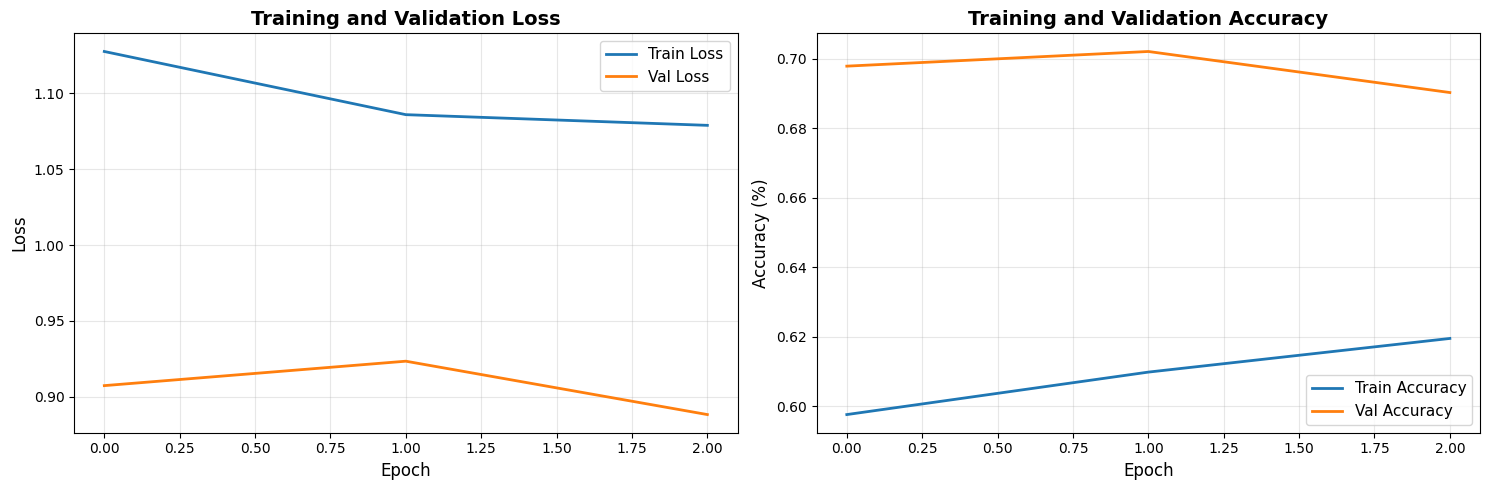

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Лосс
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Валидация модели

In [61]:
# Загружаем лучшую модель

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing'):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


test_acc = 100. * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\n{'='*60}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"{'='*60}\n")

Testing:   0%|          | 0/1 [00:00<?, ?it/s]


Test Accuracy: 68.58%



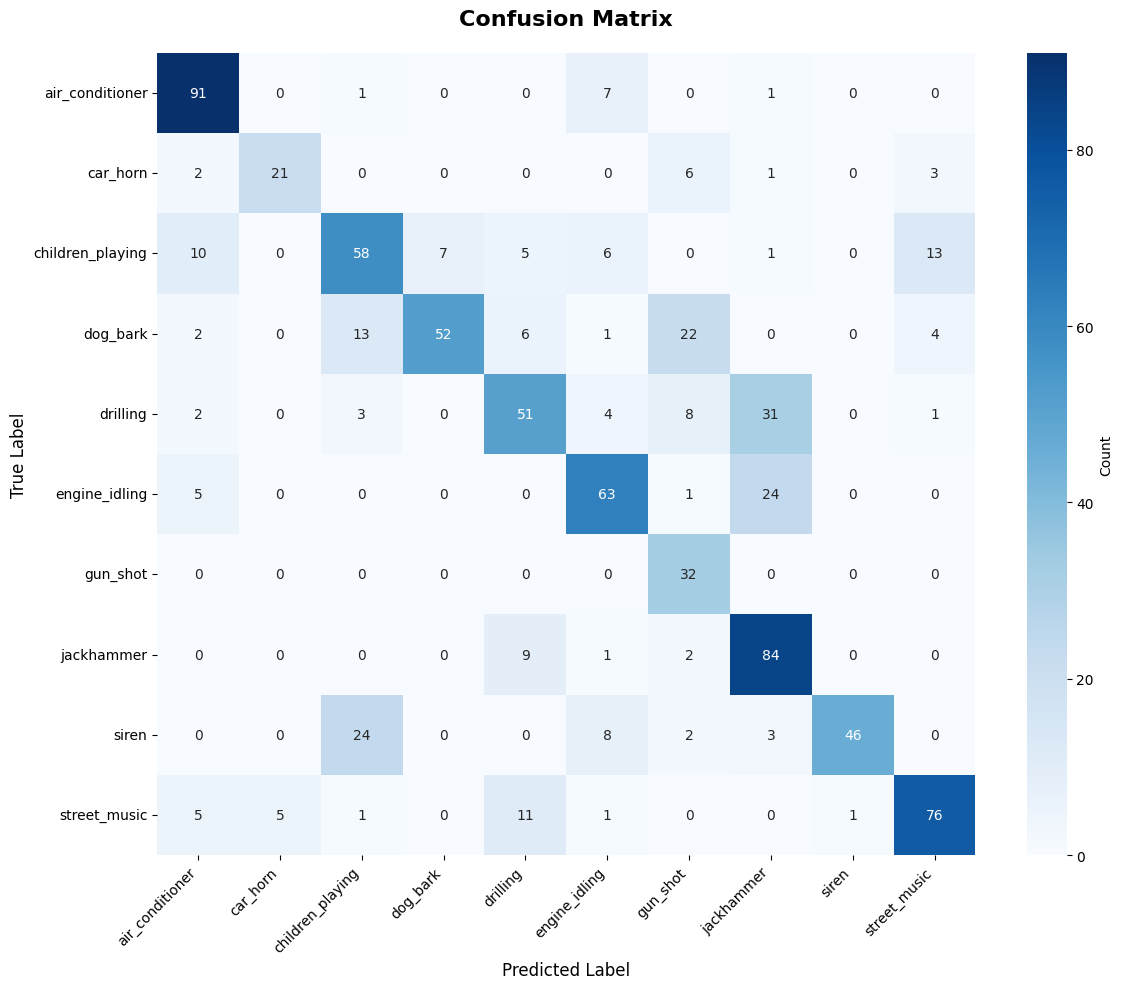

In [64]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
class_names = [
    'air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling',
    'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music'
]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [65]:
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

                  precision    recall  f1-score   support

 air_conditioner     0.7778    0.9100    0.8387       100
        car_horn     0.8077    0.6364    0.7119        33
children_playing     0.5800    0.5800    0.5800       100
        dog_bark     0.8814    0.5200    0.6541       100
        drilling     0.6220    0.5100    0.5604       100
   engine_idling     0.6923    0.6774    0.6848        93
        gun_shot     0.4384    1.0000    0.6095        32
      jackhammer     0.5793    0.8750    0.6971        96
           siren     0.9787    0.5542    0.7077        83
    street_music     0.7835    0.7600    0.7716       100

        accuracy                         0.6858       837
       macro avg     0.7141    0.7023    0.6816       837
    weighted avg     0.7245    0.6858    0.6844       837



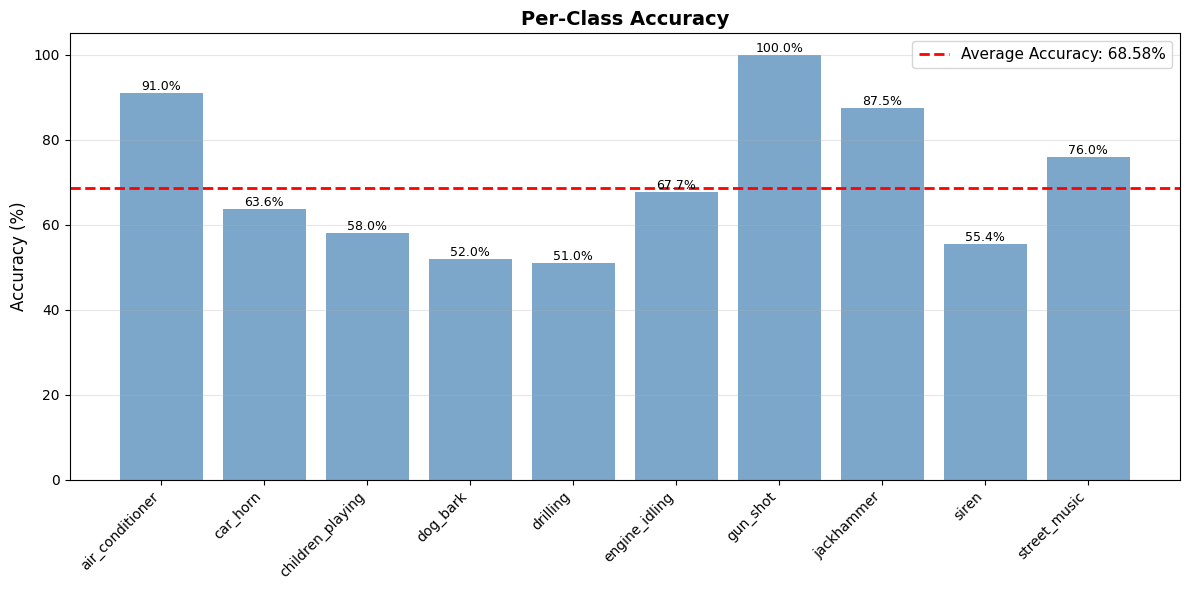

In [66]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100


plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(class_names)), per_class_acc, color='steelblue', alpha=0.7)
plt.axhline(y=test_acc, color='red', linestyle='--', label=f'Average Accuracy: {test_acc:.2f}%', linewidth=2)
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{per_class_acc[i]:.1f}%',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [67]:
print(f"Accuracy: {test_acc:.4f}")

Accuracy: 68.5783



---

## Итоги

Факторизация по координатам работает: SPINN точно воспроизводит аналитическое решение трёхмерного уравнения Гельмгольца, при этом число сетевых операций сокращается экспоненциально по сравнению с обычной PINN. Именно это отличие выводит подход за пределы демонстрационных одномерных и двумерных примеров.

Практическая ценность здесь в сценарии, где решение уравнения нужно пересчитывать многократно при разных параметрах или граничных условиях — оптимизация конструкции, цифровой двойник оборудования. Обученная модель заменяет дорогой численный солвер быстрым инференсом, а SPINN снимает ограничение на размерность.

Вторая часть иллюстрирует общий приём для сигналов произвольной природы, будь то звук, вибрация или ток: вместо сырого временного ряда — представление в частотно-временной области, подобранное под характер сигнала, а дальше обычная свёрточная сеть. Тот же конвейер применим к диагностике оборудования по акустической или вибрационной сигнатуре.
